In [140]:
import pandas as pd
import numpy as np
import pickle
import re
import random
from tqdm import tqdm_notebook


# Loading data

In [141]:
# open text file and read in data
with open("Dailog-dataset.dialogs_dataset", "rb") as f:
  dialogs = pickle.load(f)

In [142]:
random.sample(dialogs,10)

["Hello, yes I would like to make a reservation for Macaroy's",
 "Ok that's fine",
 'I think that will cover it',
 'That was first',
 'A shared ride',
 'Okay, great, have a nice day',
 'That is great, it will take be about that long to get there',
 ' I would like to order the Melazane with garlic sauce',
 'Is there anything available tomorrow afternoon?',
 "That won't work for me"]

In [186]:
dialogs[0]

"Hi, I'm looking to book a table for Korean fod"

# basic preprocessing

In [143]:
# text cleaning
dialogs_clean = []

for i in dialogs:
  # remove everything except alphabets
  i = re.sub("[^a-zA-Z' ]", "", i)
  # convert text to lowercase
  i = i.lower()
  # add cleaned text to the list
  dialogs_clean.append(i)

# Word Count

In [144]:
# get list of all the words
all_words = " ".join(dialogs_clean).split()

words_dict = {}

# add word-count pair to the dictionary
for word in all_words:   
  # check if the word is already in dictionary 
  if word in words_dict:
    # increment count of word by 1 
    words_dict[word] = words_dict[word] + 1
  else:
    # add the word to dictionary with count 1 
    words_dict[word] = 1

In [145]:
# prepare a dataframe
words_df = pd.DataFrame({'word':list(words_dict.keys()), 'count':list(words_dict.values())})

# sort words by their count in increasing order
words_df = words_df.sort_values(by = ['count'])

# reset dataframe index
words_df.reset_index(inplace = True, drop=True)

# Identify rarer words

In [146]:
# user specified threshold value
rare_thresh = 2

# get percentage of rare words in the vocabulary
rare_words_count = len(words_df[words_df['count'] < rare_thresh]['word'])
total_words = len(words_df) 
rare_dist = rare_words_count / total_words

# coverage percentage of rare words in the corpus
rare_cover = words_df[words_df['count'] < rare_thresh]['count'].sum()/words_df['count'].sum()

In [147]:
print(f"Rare words distribution in the vocabulary: {rare_dist*100:.2f}")
print(f"Rare words coverage in the corpus: {rare_cover*100:.2f}")

Rare words distribution in the vocabulary: 47.98
Rare words coverage in the corpus: 1.12


In [148]:
# extract rare words in a list
rare_words = words_df[words_df['count'] < rare_thresh]['word'].tolist()

In [149]:
len(rare_words)

5348

In [150]:
#finding pattern to identify rareword and replace them iwht <unk>
import re
pattern = ""
for i in rare_words:
  pattern+= " {} |".format(i)

# removing the last element which is "|"
pattern = pattern[:-1]

# empty list 
dialogs_clean_v2 = []

# replace the rare words with the <unk> token
for d in tqdm_notebook(dialogs_clean):
  text = re.sub(pattern, " <unk> ", d)
  dialogs_clean_v2.append(text)

C:\Users\utsav\anaconda3\envs\nlp_practice\lib\site-packages\ipykernel_launcher.py:14: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  


In [152]:
dialogu_len = []
for v in dialogs_clean_v2:
    dialogu_len.append(len(v.split()))

In [155]:
min(dialogu_len)

2

# Data Preparation

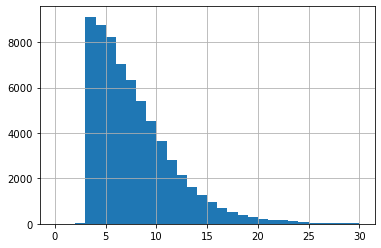

In [156]:
# capture length of all the sequences
text_word_count = []
for i in dialogs_clean_v2:
  text_word_count.append(len(i.split()))
        
# plot the sequence lengths
pd.Series(text_word_count).hist(bins = 30,range=(0,30))

In [166]:
text_word_count.count(5)

8209

In [167]:
 # function to create sequences of equal length
def create_seq(text, seq_len = 5):
      
  sequences = []    
  
  if len(text.split()) > seq_len:
    for i in range(seq_len, len(text.split())):
      #print(i)  
      # select sequence of tokens
      seq = text.split()[i-seq_len:i+1]
      # append sequence to the list
      #print(seq)  
      sequences.append(" ".join(seq))

    return sequences

  else:
    
    return [text]

In [168]:
seqs = [create_seq(i) for i in dialogs_clean_v2]

In [169]:
# merge list-of-lists into a single list
seqs = sum(seqs, [])

In [183]:
len(seqs)

205346

# convert word into integer

In [193]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts(seqs)
# Get numeric sequences.
sequences = tokenizer.texts_to_sequences(seqs)

In [194]:
vocab_size = len(tokenizer.word_counts)
print(vocab_size)

7513


In [274]:
list(tokenizer.word_counts)[7510:7512]

['pacient', 'darcy']

In [275]:
seqs[-1]

"i think we'll pass for tonight"

In [195]:
sequences

[[128, 58, 129, 1, 61, 3],
 [58, 129, 1, 61, 3, 103],
 [129, 1, 61, 3, 103, 7],
 [1, 61, 3, 103, 7, 1547],
 [61, 3, 103, 7, 1547, 5893],
 [417, 13, 3025, 1737, 269, 2],
 [13, 3025, 1737, 269, 2, 799],
 [3025, 1737, 269, 2, 799, 1164],
 [60, 97, 29, 1, 317, 26],
 [97, 29, 1, 317, 26, 2],
 [29, 1, 317, 26, 2, 308],
 [1, 317, 26, 2, 308, 56],
 [317, 26, 2, 308, 56, 919],
 [26, 2, 308, 56, 919, 241],
 [2, 308, 56, 919, 241, 12],
 [308, 56, 919, 241, 12, 100],
 [38, 210, 49, 116],
 [4238, 60, 323, 33, 211, 210],
 [138, 9, 122],
 [73, 133, 61, 10],
 [44, 67, 8, 40, 61],
 [128, 4, 27, 11, 1, 43],
 [4, 27, 11, 1, 43, 41],
 [27, 11, 1, 43, 41, 2],
 [11, 1, 43, 41, 2, 68],
 [1, 43, 41, 2, 68, 38],
 [43, 41, 2, 68, 38, 1229],
 [41, 2, 68, 38, 1229, 29],
 [2, 68, 38, 1229, 29, 12],
 [68, 38, 1229, 29, 12, 462],
 [38, 1229, 29, 12, 462, 219],
 [45, 7, 9, 6, 3, 185],
 [7, 9, 6, 3, 185, 35],
 [9, 6, 3, 185, 35, 64],
 [6, 3, 185, 35, 64, 50],
 [3, 185, 35, 64, 50, 34],
 [38, 74, 12, 10, 3026, 462],
 [

# padded to max length

In [198]:
max_sequence_len = max([len(x) for x in sequences])
input_sequences = np.array(pad_sequences(sequences, maxlen=max_sequence_len, padding='post'))

In [203]:
print(max_sequence_len)

6


In [199]:
input_sequences

array([[128,  58, 129,   1,  61,   3],
       [ 58, 129,   1,  61,   3, 103],
       [129,   1,  61,   3, 103,   7],
       ...,
       [ 60, 105, 299,   1,  43,  10],
       [105, 299,   1,  43,  10,  68],
       [  4,  63, 451, 714,   7, 106]])

In [202]:
###input data######
print("-----input data------")
X = input_sequences[:, :-1]
print(X)
print(X.shape)

####target data#####
print("-----target data------")
y = input_sequences[:, -1]
print(y)


# Convert to categorical (we add + 1 because Keras needs a placeholder).
y = to_categorical(y, num_classes=(vocab_size +1))
print(y,"convert to catgeorical")

-----input data------
[[128  58 129   1  61]
 [ 58 129   1  61   3]
 [129   1  61   3 103]
 ...
 [ 60 105 299   1  43]
 [105 299   1  43  10]
 [  4  63 451 714   7]]
(205346, 5)
-----target data------
[  3 103   7 ...  10  68 106]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]] convert to catgeorical


In [214]:
print(X.shape,y.shape)

(205346, 5) (205346, 7514)


In [204]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense


model = Sequential()
    
model.add(Embedding(input_dim=vocab_size + 1, 
                    output_dim=5, 
                    input_length=5))

model.add(LSTM(units=256, return_sequences=True))

model.add(LSTM(units=256))

model.add(Dense(units=256, activation='relu'))

model.add(Dense(units=vocab_size+1, activation='softmax'))

# model.compile(loss='categorical_crossentropy', 
#               optimizer='adam', 
#               metrics=['accuracy'])

model.summary()

Model: "sequential_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_9 (Embedding)      (None, 5, 5)              37570     
_________________________________________________________________
lstm_18 (LSTM)               (None, 5, 256)            268288    
_________________________________________________________________
lstm_19 (LSTM)               (None, 256)               525312    
_________________________________________________________________
dense_13 (Dense)             (None, 256)               65792     
_________________________________________________________________
dense_14 (Dense)             (None, 7514)              1931098   
Total params: 2,828,060
Trainable params: 2,828,060
Non-trainable params: 0
_________________________________________________________________


In [240]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy')
# Custom training loop
batch_size = 64
epochs = 50

# Define callbacks
early_stopping = EarlyStopping(monitor='accuracy', patience=2, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(filepath='keras_best_model_seq.h5', monitor='accuracy', save_best_only=True)

# Train the model
history=model.fit(X, y, epochs=epochs, 
                  batch_size=batch_size, 
                  #validation_data=(x_val_int, y_val_int), 
                  verbose=1,
                  #callbacks = [early_stopping,model_checkpoint]
                 )

Epoch 1/50
3209/3209 [==============================] - 168s 51ms/step - loss: 1.7815
Epoch 2/50
3209/3209 [==============================] - 163s 51ms/step - loss: 1.6849
Epoch 3/50
3209/3209 [==============================] - 167s 52ms/step - loss: 1.6220
Epoch 4/50
3209/3209 [==============================] - 171s 53ms/step - loss: 1.5646
Epoch 5/50
3209/3209 [==============================] - 164s 51ms/step - loss: 1.5103
Epoch 6/50
3209/3209 [==============================] - 169s 53ms/step - loss: 1.4626
Epoch 7/50
3209/3209 [==============================] - 170s 53ms/step - loss: 1.4129
Epoch 8/50
3209/3209 [==============================] - 190s 59ms/step - loss: 1.3680
Epoch 9/50
3209/3209 [==============================] - 180s 56ms/step - loss: 1.32500s - los
Epoch 10/50
3209/3209 [==============================] - 160s 50ms/step - loss: 1.2828
Epoch 11/50
3209/3209 [==============================] - 154s 48ms/step - loss: 1.2457
Epoch 12/50
3209/3209 [=====================

In [266]:
history.history.keys()

dict_keys(['loss'])

In [241]:
model.save("keras_best_model_seq.h5")
print("Saved model to disk")

Saved model to disk


In [220]:
# loss_and_metrics  =  model.evaluate(x=X, y=y)
# print("Loss:", loss_and_metrics[0])
# if len(loss_and_metrics) > 1:
#     print("Accuracy:", loss_and_metrics[1])

In [242]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def generate_text(model, tokenizer, seq_len, seed_text, num_gen_words):
    # List to store the generated words.
    output_text = []
    # Set seed_text as input_text.
    input_text = seed_text
    
    for i in range(num_gen_words):
        # Encode input text.
        encoded_text = tokenizer.texts_to_sequences([input_text])[0]
        # Add padding if the input text does not have length seq_len.
        pad_encoded = pad_sequences([encoded_text], maxlen=seq_len, truncating='pre')
        # Do the prediction.
        pred_probs = model.predict(pad_encoded, verbose=0)[0]
        # Find the index of the word with the highest probability.
        pred_word_ind = pred_probs.argmax()
        # Convert from numeric to word.
        pred_word = tokenizer.index_word[pred_word_ind]
        # Attach predicted word.
        input_text += ' ' + pred_word
        # Append new word to the list.
        output_text.append(pred_word)
        
    return ' '.join(output_text)

# # Example usage
# # Assuming `model` is your trained model, `tokenizer` is your tokenizer, `seq_len` is the sequence length used during training
# seed_text = "once upon a time"
# num_gen_words = 100
# generated_text = generate_text(model, tokenizer, seq_len, seed_text, num_gen_words)
# print(generated_text)


In [269]:
generated_text = generate_text(model=model, 
                               tokenizer=tokenizer,
                               seq_len=5, 
                               seed_text="i don't want a", 
                               num_gen_words=6)

#print(seed_text + ' ' + generated_text + '...')
print(generated_text)

get to take out from work
